# Topographic RNN diagnostics

Runs the full battery of tests that verified the `NoTimingMarkersEnv`-trained
`BioLeakyRNNTopo` actually uses the topographic `W_in_topo` (unlike the
original stim_on-shortcut version). `NoTimingMarkersEnv` zeros both
`cue_on` (ch 1) and `stim_on` (ch 4), forcing the network to route cue
and target detection through the topographic spatial channels.

Sections:
1. Setup & load checkpoint
2. Outcome distribution
3. **Lesion test** — occlude channels and measure accuracy drop
4. Per-target-location activity (cosine similarity, selectivity, eta²)
5. Topographic alignment — preferred location vs neuron sheet position
6. Linear decoder of `target_loc` from post-target activity
7. Sheet-map figure (per-location activity + selectivity + diff)

**Critical test is section 3.** If `no_spatial` lesion collapses
accuracy to ~0% → network genuinely uses spatial channels. If it stays
near baseline → network is ignoring `W_in_topo` (shortcut learning).


## 1. Setup

In [1]:
import sys

sys.path.insert(0, "..")

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from src.model_topo import BioLeakyRNNTopo
from src.env import CuedTargetWithDistractorsV3
from src.analysis import collect_trials, filter_trials

STIM_POS = CuedTargetWithDistractorsV3.STIM_POS
CKPT = "../checkpoints/stage2_topo.pt"
device = "cpu"
print("device:", device)

device: cpu


In [ ]:
# Vanilla env factory matching the training distribution in 01c_train_topo.ipynb
# (default discrete 4-corner mode). Channel layout (current):
#   0=fixation, 1=cue_x, 2=cue_y, 3=cue_strength,
#   4=stim_x,  5=stim_y, 6=stim_strength
# There is no separate timing-marker channel; strength == presence.


def make_env():
    return CuedTargetWithDistractorsV3(
        dt=20,
        cue_strength=1.0,
        p_distractor_trial=0.6,
        distractor_strength=1.0,
    )  # default continuous_locations=True -> 4 training corners


device = "cpu"
CKPT = "../checkpoints/stage2_topo.pt"

In [3]:
model = BioLeakyRNNTopo(
    input_size=7,
    hidden_size=180,
    output_size=2,
    dt=20.0,
    tau=100.0,
    activation="softplus",
    sigma_rec=0.10,
    rec_init="diag",
    use_ei=True,
    exc_ratio=0.80,
    use_dale=True,
    mask_seed=42,
    sheet_side=12,
    tau_ee=0.25,
    tau_ie=0.32,
    tau_ei=0.64,
    tau_ii=0.64,
    rf_sigma=0.3,
).to(device)
model.load_state_dict(torch.load(CKPT, weights_only=True)["state_dict"], strict=False)
model.eval()
print(f"loaded {CKPT}")
print(
    f"hidden = {model.hidden_size}, n_exc = {model.n_exc}, sheet_side = {model.sheet_side}"
)
print(f"sigma_eff = {model.sigma_eff.item():.3f}")
print(f"||W_aux|| = {model.W_aux.norm().item():.3f}, b_aux = {model.b_aux.tolist()}")

loaded ../checkpoints/stage2_topo.pt
hidden = 180, n_exc = 144, sheet_side = 12
sigma_eff = 0.316
||W_aux|| = 0.948, b_aux = [-0.005823045503348112, -0.013724099844694138]


## 2. Outcome distribution

Sanity: did the network actually learn the task?
Expect ~80% correct, <5% miss for a healthy topographic model.

In [4]:
torch.manual_seed(0)
np.random.seed(0)
trials = collect_trials(model, make_env, n_trials=2000, device=device)
ctr = Counter(t["train_outcome"] for t in trials)
total = sum(ctr.values())
for o, n in ctr.most_common():
    print(f"  {o}: {n} ({100*n/total:.1f}%)")

  correct: 1344 (67.2%)
  abort: 591 (29.6%)
  false_alarm: 59 (3.0%)
  miss: 6 (0.3%)


## 3. Lesion test

**The key test.** Run trials with individual input channels zeroed and
measure how much accuracy drops. If the network uses a channel, zeroing
it crashes accuracy.

Channel legend:
- 0 `fixation` — constant 1.0 throughout (baseline input)
- 1 `cue_on`   — 1.0 during cue epoch
- 2 `cue_x`    — cue x-coord, non-zero during cue
- 3 `cue_y`    — cue y-coord
- 4 `stim_on`  — (already zero by training, ablation env)
- 5 `stim_x`   — stim x-coord, non-zero during target/distractor
- 6 `stim_y`   — stim y-coord

**Expected if training worked:**
- `no_spatial` and `no_stim_spatial` → near 0% correct, 100% miss
- single-axis lesions (`no_stim_x` only or `no_stim_y` only) → moderate drop (network can still localize on the other axis)
- `no_cue_spatial` → ~baseline (cue spatial not critical)
- `no_cue_on`, `no_fixation` → moderate drop (timing info)

In [5]:
def run_trial(env, mask_channels=()):
    env.reset()
    x = env.ob.copy().astype(np.float32)
    gt = env.gt.copy().astype(np.int64)
    for c in mask_channels:
        x[:, c] = 0.0
    x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        logits, _ = model(x_t)
    actions = logits[0].argmax(dim=-1).numpy()
    first_release = np.where(actions == 1)[0]
    resp_on = int(first_release[0]) if len(first_release) > 0 else None
    if resp_on is None:
        return "miss"
    if gt[resp_on] == 1:
        return "correct"
    for ev in env._distractor_events:
        if ev["fa_start"] <= resp_on < ev["fa_end"]:
            return "false_alarm"
    return "abort"


# Channel layout (current):
#   0 fixation
#   1 cue_x       2 cue_y       3 cue_strength
#   4 stim_x      5 stim_y      6 stim_strength
N = 1000
conditions = {
    "baseline": [],
    "no_spatial (1,2,4,5)": [1, 2, 4, 5],
    "no_stim_spatial (4,5)": [4, 5],
    "no_cue_spatial (1,2)": [1, 2],
    "no_stim_x (4)": [4],
    "no_stim_y (5)": [5],
    "no_cue_strength (3)": [3],
    "no_stim_strength (6)": [6],
    "no_fixation (0)": [0],
}

lesion_results = {}
for name, mask in conditions.items():
    torch.manual_seed(0)
    np.random.seed(0)
    outcomes = Counter()
    for _ in range(N):
        outcomes[run_trial(make_env(), mask)] += 1
    total = sum(outcomes.values())
    acc = outcomes["correct"] / total
    lesion_results[name] = outcomes
    print(
        f'  {name:<26} correct={acc:.3f}  fa={outcomes["false_alarm"]/total:.3f}  '
        f'miss={outcomes["miss"]/total:.3f}  abort={outcomes["abort"]/total:.3f}'
    )

  baseline                   correct=0.682  fa=0.023  miss=0.003  abort=0.292


  no_spatial (1,2,4,5)       correct=0.076  fa=0.113  miss=0.408  abort=0.403


  no_stim_spatial (4,5)      correct=0.000  fa=0.000  miss=1.000  abort=0.000


  no_cue_spatial (1,2)       correct=0.061  fa=0.330  miss=0.087  abort=0.522


  no_stim_x (4)              correct=0.000  fa=0.000  miss=1.000  abort=0.000


  no_stim_y (5)              correct=0.000  fa=0.000  miss=1.000  abort=0.000


  no_cue_strength (3)        correct=0.036  fa=0.055  miss=0.903  abort=0.006


  no_stim_strength (6)       correct=0.000  fa=0.000  miss=1.000  abort=0.000


  no_fixation (0)            correct=0.000  fa=0.000  miss=0.000  abort=1.000


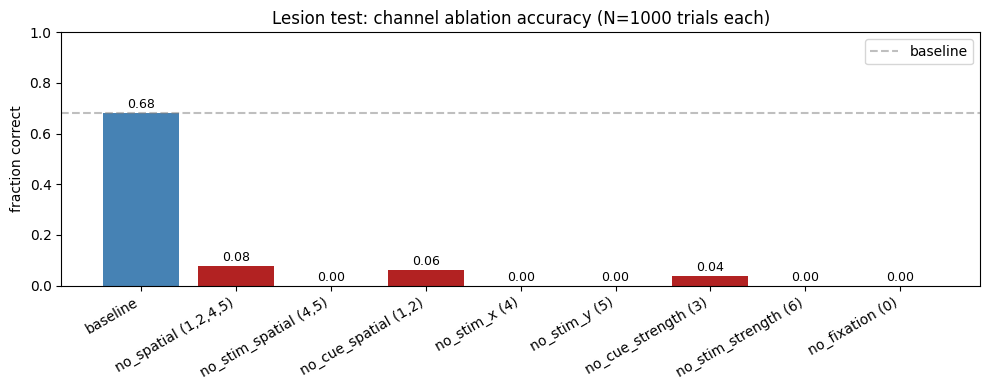

In [6]:
names = list(lesion_results.keys())
accs = [lesion_results[n]["correct"] / sum(lesion_results[n].values()) for n in names]
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(names)), accs, color=["steelblue"] + ["firebrick"] * 7)
ax.axhline(accs[0], color="gray", linestyle="--", alpha=0.5, label="baseline")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("fraction correct")
ax.set_title("Lesion test: channel ablation accuracy (N=%d trials each)" % N)
ax.set_ylim(0, 1)
ax.legend()
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width() / 2, a + 0.02, f"{a:.2f}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()

## 4. Per-target-location activity

For each correct trial, compute mean hidden activity in the 200ms window
after `target_onset`. Group by `target_loc` (1..4), look at:
- **Cosine similarity** between per-location mean activity vectors — lower = more distinct patterns
- **Selectivity** per neuron (max - min across 4 locations)
- **eta²** — fraction of per-neuron variance explained by target_loc

In [7]:
correct = filter_trials(trials, outcome="correct")


def feat(tr, window=(0, 10)):
    t0 = tr["target_onset"]
    h = tr["h"]
    a, b = t0 + window[0], t0 + window[1]
    if b > h.shape[0]:
        return None
    return h[a:b].mean(axis=0)


rows, labels = [], []
for tr in correct:
    f = feat(tr)
    if f is None:
        continue
    rows.append(f)
    labels.append(tr["target_loc"])
X = np.stack(rows)
y = np.array(labels)
n_exc = model.n_exc
X_exc = X[:, :n_exc]
print(f"feature matrix: {X.shape}, per-loc counts: {np.bincount(y)[1:]}")

per_loc_mean = np.stack([X_exc[y == loc].mean(axis=0) for loc in (1, 2, 3, 4)])

feature matrix: (1344, 180), per-loc counts: [488 128 461 267]


In [8]:
print("Cosine similarity between per-loc E-activity vectors:")
for a in range(4):
    for b in range(a + 1, 4):
        ca, cb = per_loc_mean[a], per_loc_mean[b]
        cos = (ca @ cb) / (np.linalg.norm(ca) * np.linalg.norm(cb) + 1e-12)
        print(
            f"  loc{a+1} vs loc{b+1}:  cos={cos:+.4f}  mean|diff|={np.abs(ca-cb).mean():.3f}"
        )

sel = per_loc_mean.max(axis=0) - per_loc_mean.min(axis=0)
print(f"\nSelectivity (max-min of mean h across 4 locs) over {n_exc} E neurons:")
print(
    f"  median={np.median(sel):.3f}  p95={np.percentile(sel, 95):.3f}  max={sel.max():.3f}"
)

total_var = X_exc.var(axis=0)
between_var = np.zeros(n_exc)
for loc in (1, 2, 3, 4):
    m_loc = X_exc[y == loc].mean(axis=0)
    grand = X_exc.mean(axis=0)
    p = (y == loc).mean()
    between_var += p * (m_loc - grand) ** 2
eta2 = between_var / (total_var + 1e-12)
print(f"\neta^2 (fraction of per-neuron variance explained by target_loc):")
print(
    f"  median={np.median(eta2):.3f}  p90={np.percentile(eta2, 90):.3f}  max={eta2.max():.3f}"
)

Cosine similarity between per-loc E-activity vectors:
  loc1 vs loc2:  cos=+0.2059  mean|diff|=2.482
  loc1 vs loc3:  cos=+0.2745  mean|diff|=2.679
  loc1 vs loc4:  cos=+0.3283  mean|diff|=2.754
  loc2 vs loc3:  cos=+0.2289  mean|diff|=1.967
  loc2 vs loc4:  cos=+0.2558  mean|diff|=2.217
  loc3 vs loc4:  cos=+0.3525  mean|diff|=2.244

Selectivity (max-min of mean h across 4 locs) over 144 E neurons:
  median=1.951  p95=21.382  max=56.813

eta^2 (fraction of per-neuron variance explained by target_loc):
  median=0.965  p90=0.991  max=0.998


## 4b. Pre-target temporal activity (per target_loc)


C:\Users\savoj\AppData\Local\Temp\ipykernel_30200\33116383.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


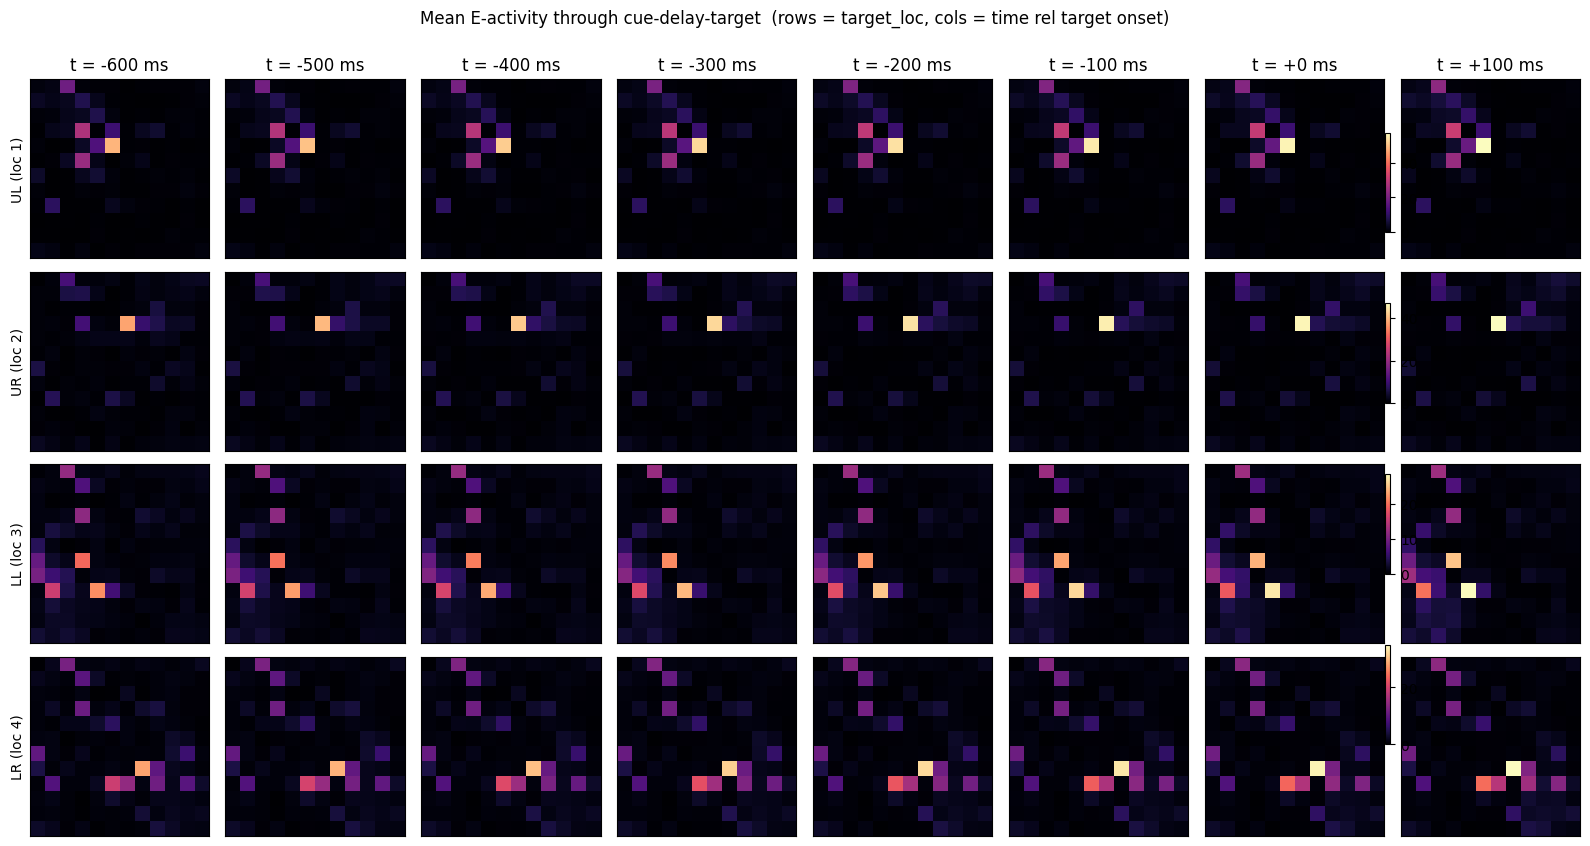


Trial counts per loc x offset (within correct):
  loc 1: [488, 488, 488, 488, 488, 488, 488, 488]
  loc 2: [128, 128, 128, 128, 128, 128, 128, 128]
  loc 3: [461, 461, 461, 461, 461, 461, 461, 461]
  loc 4: [267, 267, 267, 267, 267, 267, 267, 267]


In [9]:
# For each target_loc, show how the E-activity sheet-pattern evolves through
# the pre-target window (cue onset -> target onset) -- averaged across trials.
#
# Each trial has its own variable delay (CTOA), so we ALIGN to target onset
# and show snapshots at t = target_onset + offset_ms, with negative offsets
# meaning "before target".

offsets_ms = [-600, -500, -400, -300, -200, -100, 0, +100]
dt_ms = 20
side = model.sheet_side
n_exc = model.n_exc

e_xy_n = model.coords[:n_exc].cpu().numpy()
denom = max(1.0, float(side - 1))
e_grid = np.rint((e_xy_n + 1.0) * 0.5 * denom).astype(int)

per_loc_snapshots = {loc: {ms: [] for ms in offsets_ms} for loc in (1, 2, 3, 4)}
for tr in correct:
    loc = int(tr["target_loc"])
    if loc not in (1, 2, 3, 4):
        continue
    t0 = int(tr["target_onset"])
    h = tr["h"]
    T_trial = h.shape[0]
    for ms in offsets_ms:
        t_idx = t0 + ms // dt_ms
        if 0 <= t_idx < T_trial:
            per_loc_snapshots[loc][ms].append(h[t_idx, :n_exc])

fig, axes = plt.subplots(4, len(offsets_ms), figsize=(2.0 * len(offsets_ms), 8.5))
loc_lbl = {1: "UL (loc 1)", 2: "UR (loc 2)", 3: "LL (loc 3)", 4: "LR (loc 4)"}

for r, loc in enumerate((1, 2, 3, 4)):
    snaps = []
    for ms in offsets_ms:
        bucket = per_loc_snapshots[loc][ms]
        if not bucket:
            snaps.append(None)
            continue
        mean_h = np.mean(bucket, axis=0)
        snaps.append(mean_h)
    valid = [s for s in snaps if s is not None]
    vmax = max(np.abs(s).max() for s in valid) if valid else 1.0
    for c, (ms, mean_h) in enumerate(zip(offsets_ms, snaps)):
        ax = axes[r, c]
        if mean_h is None:
            ax.axis("off")
            continue
        grid = np.full((side, side), np.nan)
        for k, (xg, yg) in enumerate(e_grid):
            grid[yg, xg] = mean_h[k]
        im = ax.imshow(grid, origin="lower", cmap="magma", vmin=0, vmax=vmax)
        ax.set_xticks([])
        ax.set_yticks([])
        if r == 0:
            ax.set_title(f"t = {ms:+d} ms")
        if c == 0:
            ax.set_ylabel(loc_lbl[loc], fontsize=10)
    plt.colorbar(im, ax=axes[r], shrink=0.7, fraction=0.04, pad=0.02)

fig.suptitle(
    "Mean E-activity through cue-delay-target  "
    "(rows = target_loc, cols = time rel target onset)",
    y=1.00,
)
plt.tight_layout()
plt.savefig("../figures/topo_diag_pretarget_temporal.png", dpi=120, bbox_inches="tight")
plt.show()

print()
print("Trial counts per loc x offset (within correct):")
for loc in (1, 2, 3, 4):
    counts = [len(per_loc_snapshots[loc][ms]) for ms in offsets_ms]
    print(f"  loc {loc}: {counts}")

## 5. Topographic alignment

For each E neuron, find its preferred target location (argmax across 4).
Does the neuron's physical position on the sheet correlate with the
stim_x/stim_y of its preferred target? If yes → topographic code
preserved after training.

In [10]:
STIM_POS = CuedTargetWithDistractorsV3.STIM_POS

# E neuron sheet positions, already in [-1, 1]^2 (not integer grid).
e_xy = model.coords[:n_exc].cpu().numpy()
nx, ny = e_xy[:, 0], e_xy[:, 1]
side = model.sheet_side

pref_loc = np.argmax(per_loc_mean, axis=0) + 1  # 1..4 per neuron
pref_stim_x = np.array([STIM_POS[int(p)][0] for p in pref_loc])
pref_stim_y = np.array([STIM_POS[int(p)][1] for p in pref_loc])

w = sel / (sel.sum() + 1e-12)


def w_corr(a, b, w):
    ma = (a * w).sum()
    mb = (b * w).sum()
    va = ((a - ma) ** 2 * w).sum()
    vb = ((b - mb) ** 2 * w).sum()
    return ((a - ma) * (b - mb) * w).sum() / (np.sqrt(va * vb) + 1e-12)


print("corr(neuron sheet-position,  preferred stim-position):")
print(f"  x unweighted = {np.corrcoef(nx, pref_stim_x)[0,1]:+.3f}")
print(f"  y unweighted = {np.corrcoef(ny, pref_stim_y)[0,1]:+.3f}")
print(f"  x weighted   = {w_corr(nx, pref_stim_x, w):+.3f}")
print(f"  y weighted   = {w_corr(ny, pref_stim_y, w):+.3f}")

corr(neuron sheet-position,  preferred stim-position):
  x unweighted = +0.704
  y unweighted = +0.503
  x weighted   = +0.692
  y weighted   = +0.767


## 6. Linear decoder of target_loc

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

clf = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=2000, multi_class="multinomial")
)
scores_exc = cross_val_score(clf, X_exc, y, cv=5, scoring="accuracy")
scores_full = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print(
    f"5-fold CV decoding accuracy (E only): {scores_exc.mean():.3f}   per fold: {scores_exc.round(3).tolist()}"
)
print(f"5-fold CV decoding accuracy (all H):  {scores_full.mean():.3f}")
print(f"chance: 0.250")

5-fold CV decoding accuracy (E only): 1.000   per fold: [1.0, 1.0, 1.0, 1.0, 1.0]
5-fold CV decoding accuracy (all H):  1.000
chance: 0.250


## 7. Sheet-map figure

Top row: mean activity map per target_loc (E sheet only).
Bottom row: selectivity, eta², preferred-location, and diff(loc2-loc1)
(the latter should show a left→right gradient since loc2 has `stim_x=+1`
and loc1 has `stim_x=-1`).

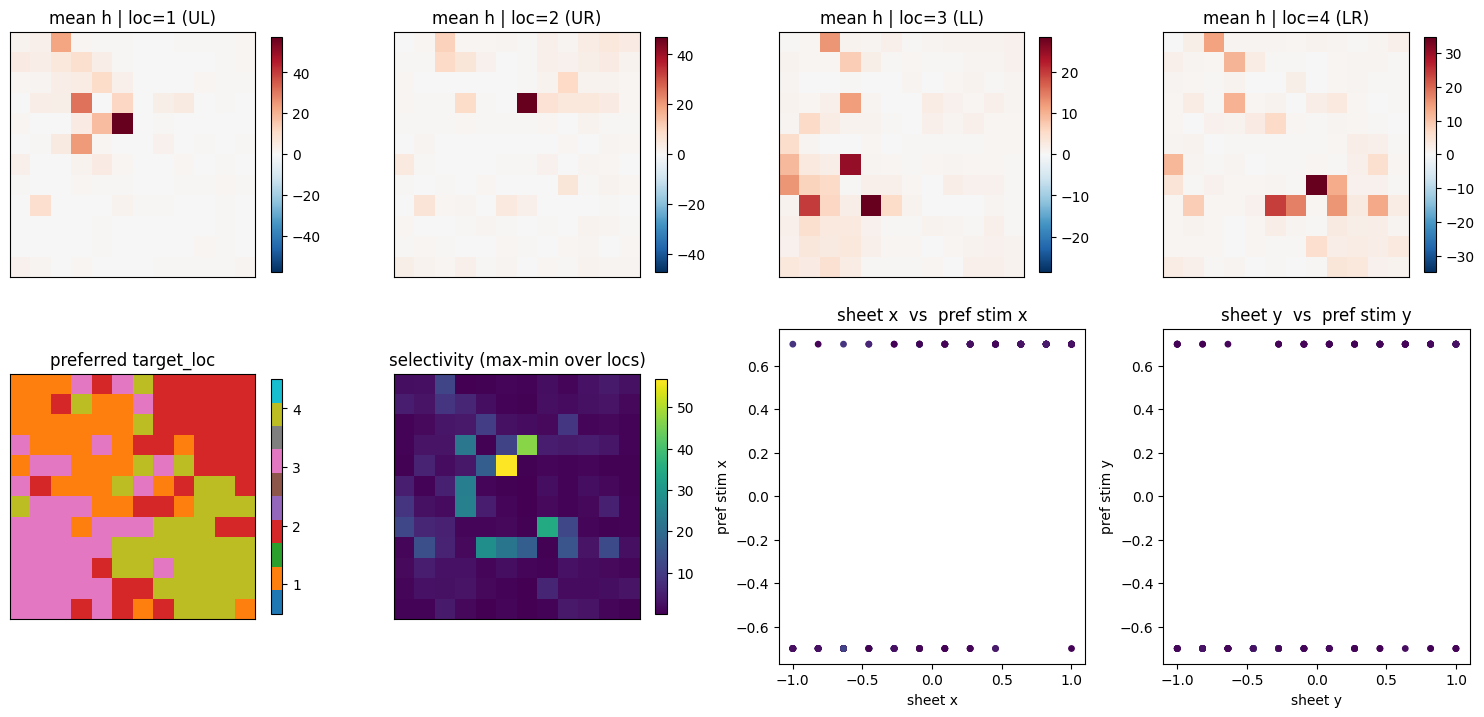

In [12]:
# Map E coords back to integer grid indices for imshow.
e_xy_n = model.coords[:n_exc].cpu().numpy()
denom = max(1.0, float(side - 1))
e_grid = np.rint((e_xy_n + 1.0) * 0.5 * denom).astype(int)  # [n_exc, 2]

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
loc_lbl = {1: "UL", 2: "UR", 3: "LL", 4: "LR"}

# Row 0: per-location activity maps
for i, loc in enumerate((1, 2, 3, 4)):
    grid = np.full((side, side), np.nan)
    for k, (xg, yg) in enumerate(e_grid):
        grid[yg, xg] = per_loc_mean[loc - 1, k]
    vmax = np.nanmax(np.abs(grid))
    im = axes[0, i].imshow(grid, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[0, i].set_title(f"mean h | loc={loc} ({loc_lbl[loc]})")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    plt.colorbar(im, ax=axes[0, i], shrink=0.7)

# Row 1: preferred-loc map (which target this neuron prefers)
pref_grid = np.full((side, side), np.nan)
sel_grid = np.full((side, side), np.nan)
for k, (xg, yg) in enumerate(e_grid):
    pref_grid[yg, xg] = pref_loc[k]
    sel_grid[yg, xg] = sel[k]
im = axes[1, 0].imshow(pref_grid, origin="lower", cmap="tab10", vmin=0.5, vmax=4.5)
axes[1, 0].set_title("preferred target_loc")
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])
plt.colorbar(im, ax=axes[1, 0], shrink=0.7, ticks=[1, 2, 3, 4])

im = axes[1, 1].imshow(sel_grid, origin="lower", cmap="viridis")
axes[1, 1].set_title("selectivity (max-min over locs)")
axes[1, 1].set_xticks([])
axes[1, 1].set_yticks([])
plt.colorbar(im, ax=axes[1, 1], shrink=0.7)

# Row 1 col 2-3: pref_stim_x / pref_stim_y vs sheet pos (preview)
axes[1, 2].scatter(nx, pref_stim_x, c=sel, s=15, cmap="viridis")
axes[1, 2].set_title("sheet x  vs  pref stim x")
axes[1, 2].set_xlabel("sheet x")
axes[1, 2].set_ylabel("pref stim x")
axes[1, 3].scatter(ny, pref_stim_y, c=sel, s=15, cmap="viridis")
axes[1, 3].set_title("sheet y  vs  pref stim y")
axes[1, 3].set_xlabel("sheet y")
axes[1, 3].set_ylabel("pref stim y")

plt.tight_layout()
plt.savefig("../figures/topo_diagnostics_sheet.png", dpi=120, bbox_inches="tight")
plt.show()

## Interpretation cheat sheet

| Probe | Healthy topographic network | Shortcut network |
|---|---|---|
| task correct | ~80% | ~80% |
| `no_spatial` lesion | **0%** correct (collapse) | 80% (unchanged) |
| `no_stim_spatial` (5,6) | **0%** correct | 80% |
| cosine sim per-loc | 0.95–0.99 (with large mean\|diff\|) | >0.998 (tiny diff) |
| selectivity median | >1.0 | <0.5 |
| eta² median | >0.5 | <0.05 |
| topo corr(neuron_x, pref_x) | ~+0.5–+0.8 | ~+0.7 (passive) |
| linear decoder acc | ~100% | ~100% (passive) |

**Critical distinction:** the shortcut network has topographic info
present in `h` (because `W_in_topo` is frozen and always drives the
sheet), so the decoder and topographic correlation metrics look good
in both cases. Only the **lesion test** distinguishes passive injection
from active use.
